# Generic Notebook to explore data

In [29]:
## Imports
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm import tqdm
# Parameters
PATCH_DATA_DIR = 'D:/Data_CHU/data_bloc_224/HE/'

## Patch overview

In [30]:
def count_files_per_subfolder(root_path: str):
    root = Path(root_path)

    # On ne prend QUE les sous-dossiers directs
    subfolders = [f for f in root.iterdir() if f.is_dir()]

    folder_counts = []

    for folder in tqdm(subfolders, desc="Scanning subfolders"):
        try:
            count = len([f for f in folder.iterdir() if f.is_file()])
            folder_counts.append((str(folder), count))
        except PermissionError:
            continue

    return folder_counts

# ===== USAGE =====
root_path = PATCH_DATA_DIR

folder_counts = count_files_per_subfolder(root_path)


# Affichage de quelques résultats
folder_counts[:-10]

Scanning subfolders: 100%|██████████| 66/66 [04:17<00:00,  3.90s/it]


[('D:\\Data_CHU\\data_bloc_224\\HE\\25P11214', 0),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P11397', 3008),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P11414', 304),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P12995', 38784),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P13027', 27376),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P16493', 37104),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P16544', 256),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P16569', 11872),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P17513', 11840),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P18069', 47488),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P18147', 61264),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P18616', 18256),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P18860', 24288),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P19032', 30432),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P19078', 72864),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P19219', 22608),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P20177', 45360),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P20417', 10048),
 ('D:\\Data_CHU\\da

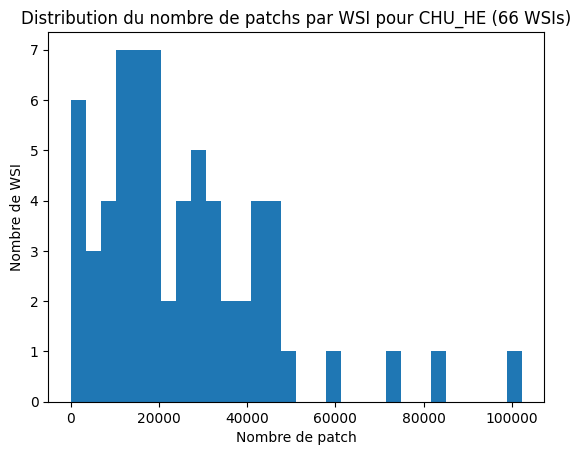

In [31]:


def plot_distribution(folder_counts,title):
    counts = [c for _, c in folder_counts]

    plt.figure()
    plt.hist(counts, bins=30)
    plt.title(title)
    plt.xlabel("Nombre de patch")
    plt.ylabel("Nombre de WSI")
    plt.show()


plot_distribution(folder_counts,f"Distribution du nombre de patchs par WSI pour CHU_HE ({len(folder_counts)} WSIs)")


In [33]:
sorted(folder_counts, key=lambda x: x[1], reverse=True)[-10:]

[('D:\\Data_CHU\\data_bloc_224\\HE\\25P6193', 7040),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P8589', 6160),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P41007', 6144),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P9546_1', 5232),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P27185', 3360),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P11397', 3008),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P7883', 528),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P11414', 304),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P16544', 256),
 ('D:\\Data_CHU\\data_bloc_224\\HE\\25P11214', 0)]

In [27]:
from pathlib import Path
from tqdm import tqdm

def count_files_per_B_folder(root_path: str):
    root = Path(root_path)

    # dossiers B = enfants directs de A
    B_folders = [p for p in root.iterdir() if p.is_dir()]

    results = []

    for B in tqdm(B_folders, desc="Processing B folders"):
        try:
            # tous les fichiers récursifs sous B
            count = sum(1 for f in B.rglob("*") if f.is_file())
            results.append((str(B), count*16))
        except PermissionError:
            results.append((str(B), 0))

    return results

Processing B folders: 100%|██████████| 60/60 [00:01<00:00, 40.14it/s]


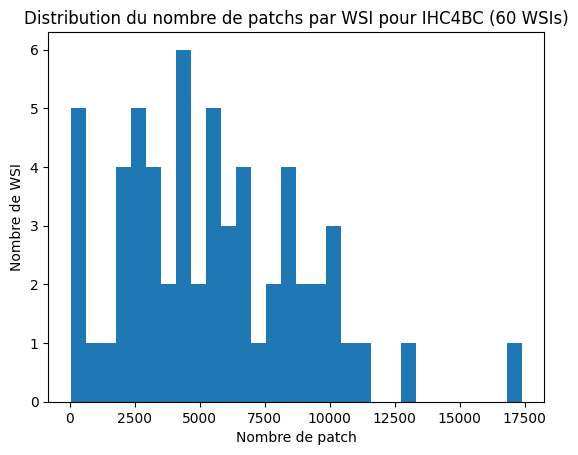

In [28]:
root_path = "C:/Users/manon/Desktop/data/IHC4BC_Compressed/Images/HandE/Ki67/"

folder_counts = count_files_per_B_folder(root_path)
plot_distribution(folder_counts,f"Distribution du nombre de patchs par WSI pour IHC4BC ({len(folder_counts)} WSIs)")

# Analyzing Embeddings

In [125]:
## Imports
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
## Parameters

EMBEDDINGS_UNI_DIR = "D:/Embeddings/HER2MATCH/HER2MATCH_224_UNI2_embeds/HE/" # subfolders test train val
EMBEDDINGS_GIGAPATH_DIR  = "C:/Users/manon/Documents/pathology_MIL/data/HER2MATCH_GIGAPATH_embeds/HE/"
GIGAPATH_LABELS_DIR = "D:/Datasets/HER2SCORES_224.txt"
GIGAPATH_LABELS_DIR_reducted = "D:/Datasets/dataset_labels.txt"

In [100]:


def load_embeddings(folder_paths, dataset_key=None, pad_value=0.0):
    """
    Charge des embeddings .h5 de tailles variables et applique un padding
    pour obtenir une matrice homogène.
    
    Returns:
        X: np.array (n_samples, max_dim)
        files: list of filenames
    """

    embeddings = []
    files = []
    dims = []

    # --------- LOAD ----------
    for folder in folder_paths:
        folder = Path(folder)

        for file in folder.rglob("*.h5"):
            with h5py.File(file, "r") as f:

                key = dataset_key or list(f.keys())[0]
                emb = np.array(f[key][:]).reshape(-1)

                embeddings.append(emb)
                files.append(file.name)
                dims.append(emb.shape[0])

    # --------- PAD ----------
    max_dim = max(dims)

    X = np.full((len(embeddings), max_dim), pad_value, dtype=np.float32)

    for i, emb in enumerate(embeddings):
        X[i, :emb.shape[0]] = emb

    return X, files

In [101]:
folder_path = [EMBEDDINGS_GIGAPATH_DIR+'test/',EMBEDDINGS_GIGAPATH_DIR+'train/', EMBEDDINGS_GIGAPATH_DIR+'val/']
X, files = load_embeddings(folder_path, dataset_key=None)

In [126]:
def load_labels(txt_path, files):
    """
    Charge des labels depuis un fichier .txt séparé par ';'
    
    Format attendu :
        slide_id;label
        file1.h5;A
        file2.h5;B
    """

    df = pd.read_csv(txt_path, sep=";")

    label_map = dict(zip(df["slide_id"], df["label"]))

    labels = [label_map[f] for f in files]

    le = LabelEncoder()
    y = le.fit_transform(labels)

    return y, le


# OPTION labels
labels_csv = GIGAPATH_LABELS_DIR
labels_csv_reducted = GIGAPATH_LABELS_DIR_reducted
y, le = load_labels(labels_csv, files)
y_red, le_red= load_labels(labels_csv_reducted,files)


In [103]:
X

array([[ 45056.,  59392.,  45056., ...,      0.,      0.,      0.],
       [ 45056.,  59392.,  45056., ...,      0.,      0.,      0.],
       [ 45056.,  59392.,  45056., ...,      0.,      0.,      0.],
       ...,
       [ 56320., 129024.,  56320., ...,      0.,      0.,      0.],
       [ 56320., 129024.,  56320., ...,      0.,      0.,      0.],
       [ 56320., 129024.,  56320., ...,      0.,      0.,      0.]],
      shape=(17, 371520), dtype=float32)

In [114]:
y

array([0, 1, 3, 2, 0, 0, 3, 0, 3, 1, 2, 0, 3, 1, 1, 0, 2])

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt

def run_pca_lda(X, FM_label, y=None):
    
    # PCA
    pca = PCA(n_components=4)
    X = np.array(X)
    X_pca = pca.fit_transform(X)

    plt.figure()
    if y is not None:
        plt.scatter(X_pca[:, 1], X_pca[:, 1], c=y, cmap="tab10", s=10)
    else:
        plt.scatter(X_pca[:, 0], X_pca[:, 1], s=10)

    plt.title(f"PCA - Embeddings {FM_label}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.show()

    plt.figure()

    # density background
    sns.kdeplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        fill=True,
        cmap="Greys",
        levels=40,
        alpha=0.5
    )

    # points par classe
    sns.scatterplot(
        x=X_pca[:, 0],
        y=X_pca[:, 1],
        hue=y,
        palette="tab10",
        s=50,
        edgecolor="black"
    )

    plt.title(f"PCA - {FM_label} embeddings with density + labels")
    plt.show()
    X_pca_df = pd.DataFrame(X_pca,columns=['PC1','PC2','PC3','PC4'])

    plt.figure()
    sns.set_theme(style="white")


    # Plot miles per gallon against horsepower with other semantics
    sns.relplot(x='PC1', y='PC2', hue=y,size=y,
                sizes=(40, 400), alpha=.5, palette="muted",
                height=6, data=X_pca_df)
    plt.title(f"PCA - {FM_label} embeddings with density + labels")
    plt.show()


    # LDA (si labels disponibles)
    if y is not None:
        lda = LDA(n_components=2)
        X_lda = lda.fit_transform(X, y)

        plt.figure()
        plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap="tab10", s=10)
        plt.title("LDA - Embeddings")
        plt.xlabel("LD1")
        plt.ylabel("LD2")
        plt.show()

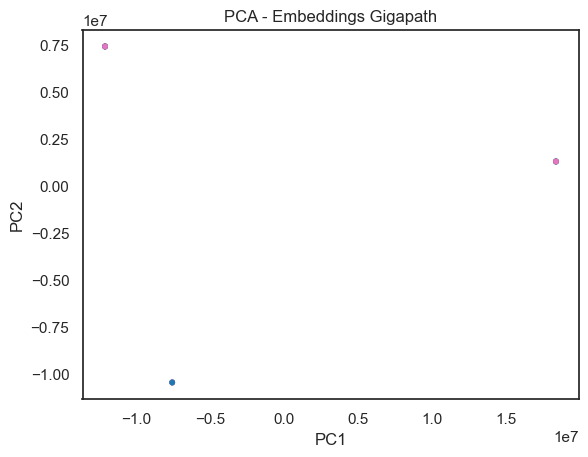

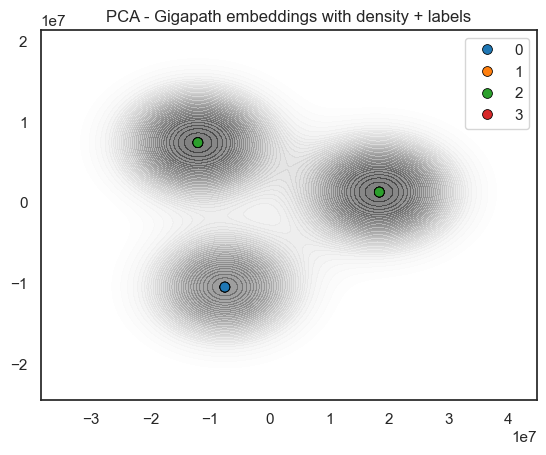

<Figure size 640x480 with 0 Axes>

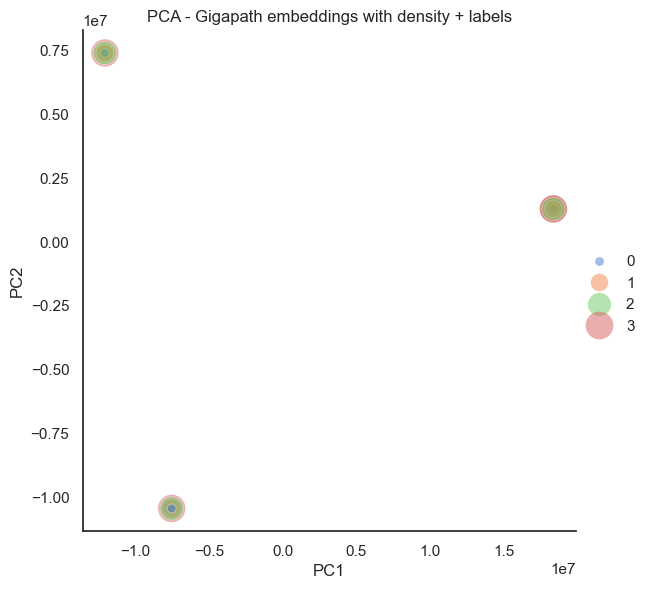

In [128]:
run_pca_lda(X,'Gigapath',y)

<Figure size 640x480 with 0 Axes>

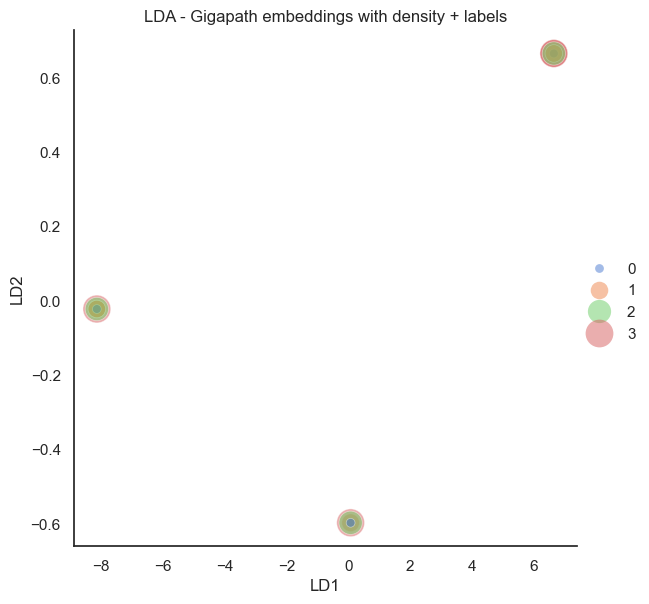

In [133]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)
X_lda_df = pd.DataFrame(X_lda,columns=['LD1','LD2'])

plt.figure()
sns.set_theme(style="white")


    # Plot miles per gallon against horsepower with other semantics
sns.relplot(x='LD1', y='LD2', hue=y,size=y,
                sizes=(40, 400), alpha=.5, palette="muted",
                height=6, data=X_lda_df)
plt.title(f"LDA - Gigapath embeddings with density + labels")
plt.show()


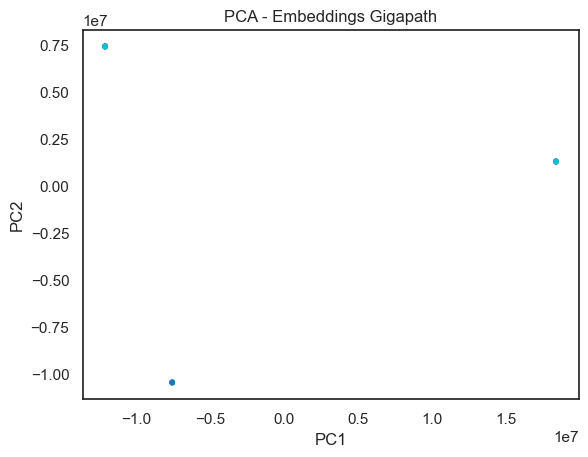

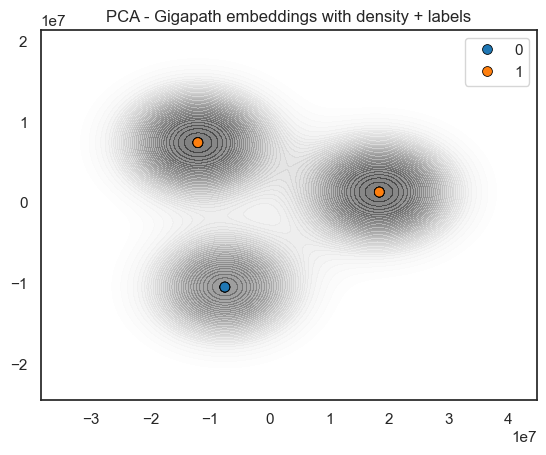

<Figure size 640x480 with 0 Axes>

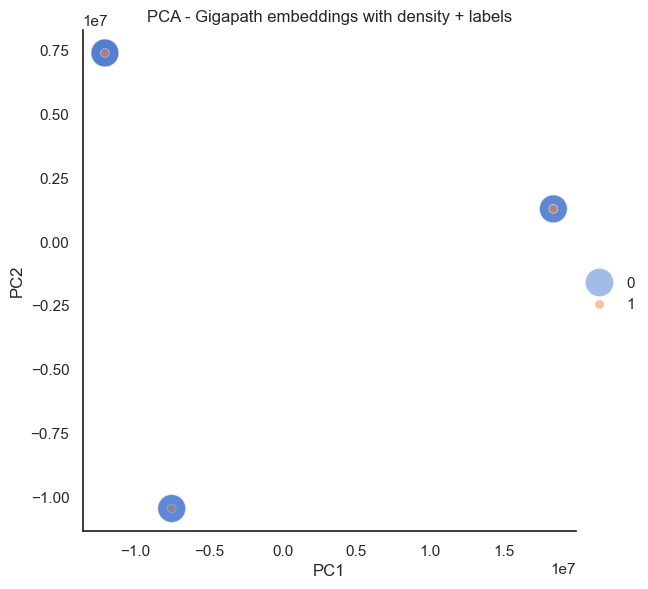

In [127]:
run_pca_lda(X,'Gigapath',y_red)

In [134]:
folder_path = [EMBEDDINGS_UNI_DIR+'test/',EMBEDDINGS_UNI_DIR+'train/', EMBEDDINGS_UNI_DIR+'val/']
X, files = load_embeddings(folder_path, dataset_key=None)
labels_csv = GIGAPATH_LABELS_DIR
y, le = load_labels(labels_csv, files)




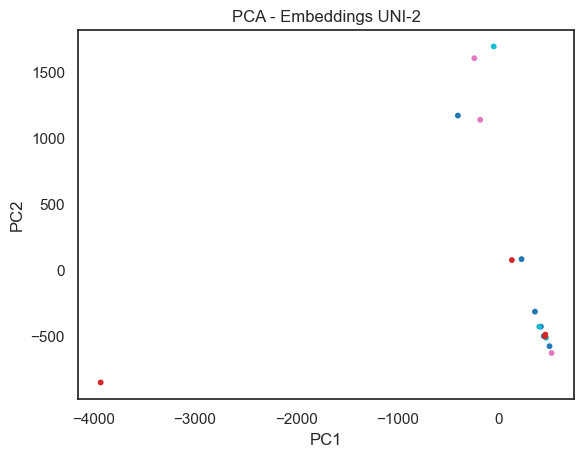

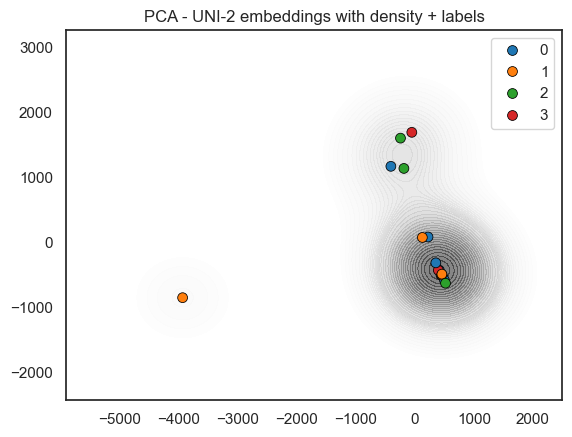

<Figure size 640x480 with 0 Axes>

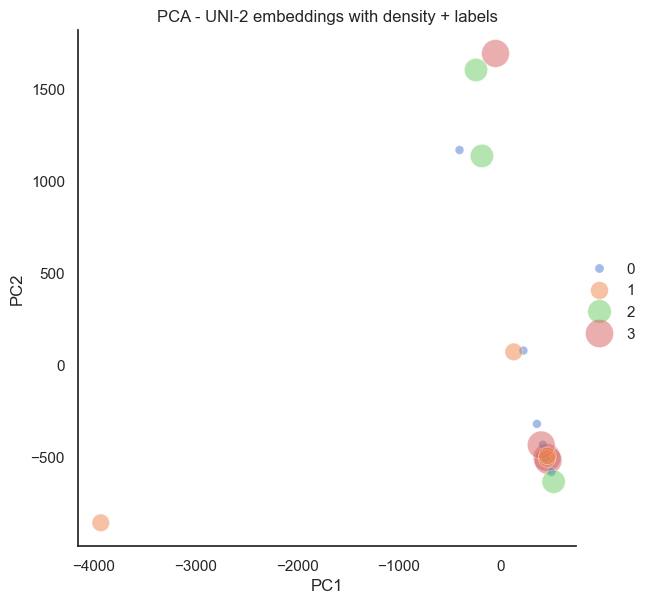

In [135]:
run_pca_lda(X, 'UNI-2', y)

<Figure size 640x480 with 0 Axes>

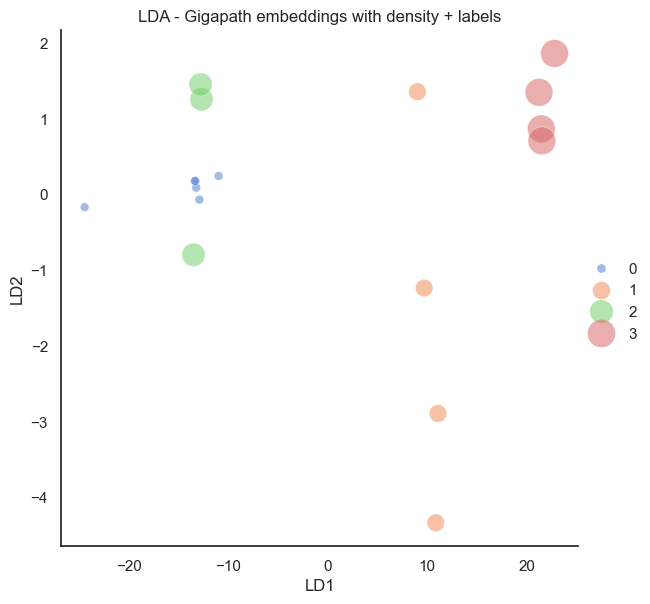

In [136]:
lda = LDA(n_components=2)
X_lda = lda.fit_transform(X, y)
X_lda_df = pd.DataFrame(X_lda,columns=['LD1','LD2'])

plt.figure()
sns.set_theme(style="white")


    # Plot miles per gallon against horsepower with other semantics
sns.relplot(x='LD1', y='LD2', hue=y,size=y,
                sizes=(40, 400), alpha=.5, palette="muted",
                height=6, data=X_lda_df)
plt.title(f"LDA - Gigapath embeddings with density + labels")
plt.show()
